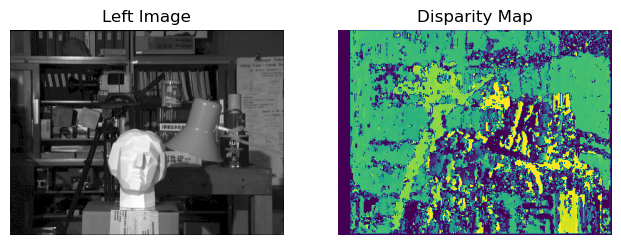

In [10]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

imgL = cv.imread('tsukuba_l.png', cv.IMREAD_GRAYSCALE)
imgR = cv.imread('tsukuba_r.png', cv.IMREAD_GRAYSCALE)

# imgL = cv.imread('im2left.png', cv.IMREAD_GRAYSCALE)
# imgR = cv.imread('im2right.png', cv.IMREAD_GRAYSCALE)

#-------------------------------------------------------------
# imgL = cv.imread('im0left.png', cv.IMREAD_GRAYSCALE)    #---
# imgR = cv.imread('im0right.png', cv.IMREAD_GRAYSCALE)   #---
                                                          #---
# imgL = cv.imread('im1left.png', cv.IMREAD_GRAYSCALE)    #---
# imgR = cv.imread('im1right.png', cv.IMREAD_GRAYSCALE)   #---
#-------------------------------------------------------------



# Stereo Block Matching
stereo = cv.StereoBM_create(numDisparities=16, blockSize=5)
disparity = stereo.compute(imgL,imgR)

# Plot the results
plt.figure(figsize=(12, 6))
plt.subplot(131), plt.imshow(imgL, cmap= "gray"), plt.title('Left Image'), plt.axis('off')
plt.subplot(132), plt.imshow(disparity), plt.title('Disparity Map'), plt.axis('off')
plt.show()

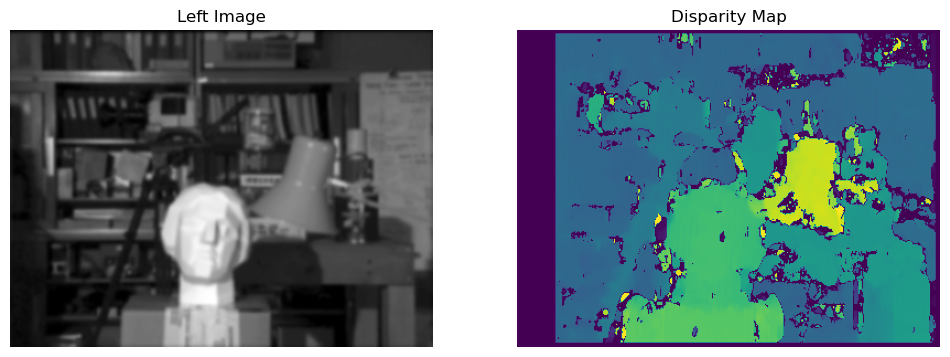

In [12]:
# Preprocessing
imgL = cv.GaussianBlur(imgL, (5, 5), 0)
imgR = cv.GaussianBlur(imgR, (5, 5), 0)


# Stereo Block Matching
stereo = cv.StereoBM_create(numDisparities=32, blockSize=9)  # Adjust parameters
disparity = stereo.compute(imgL, imgR)



# Plot the results
# Plot the results
plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(imgL, cmap= "gray"), plt.title('Left Image'), plt.axis('off')
plt.subplot(122), plt.imshow(disparity), plt.title('Disparity Map'), plt.axis('off')
plt.show()

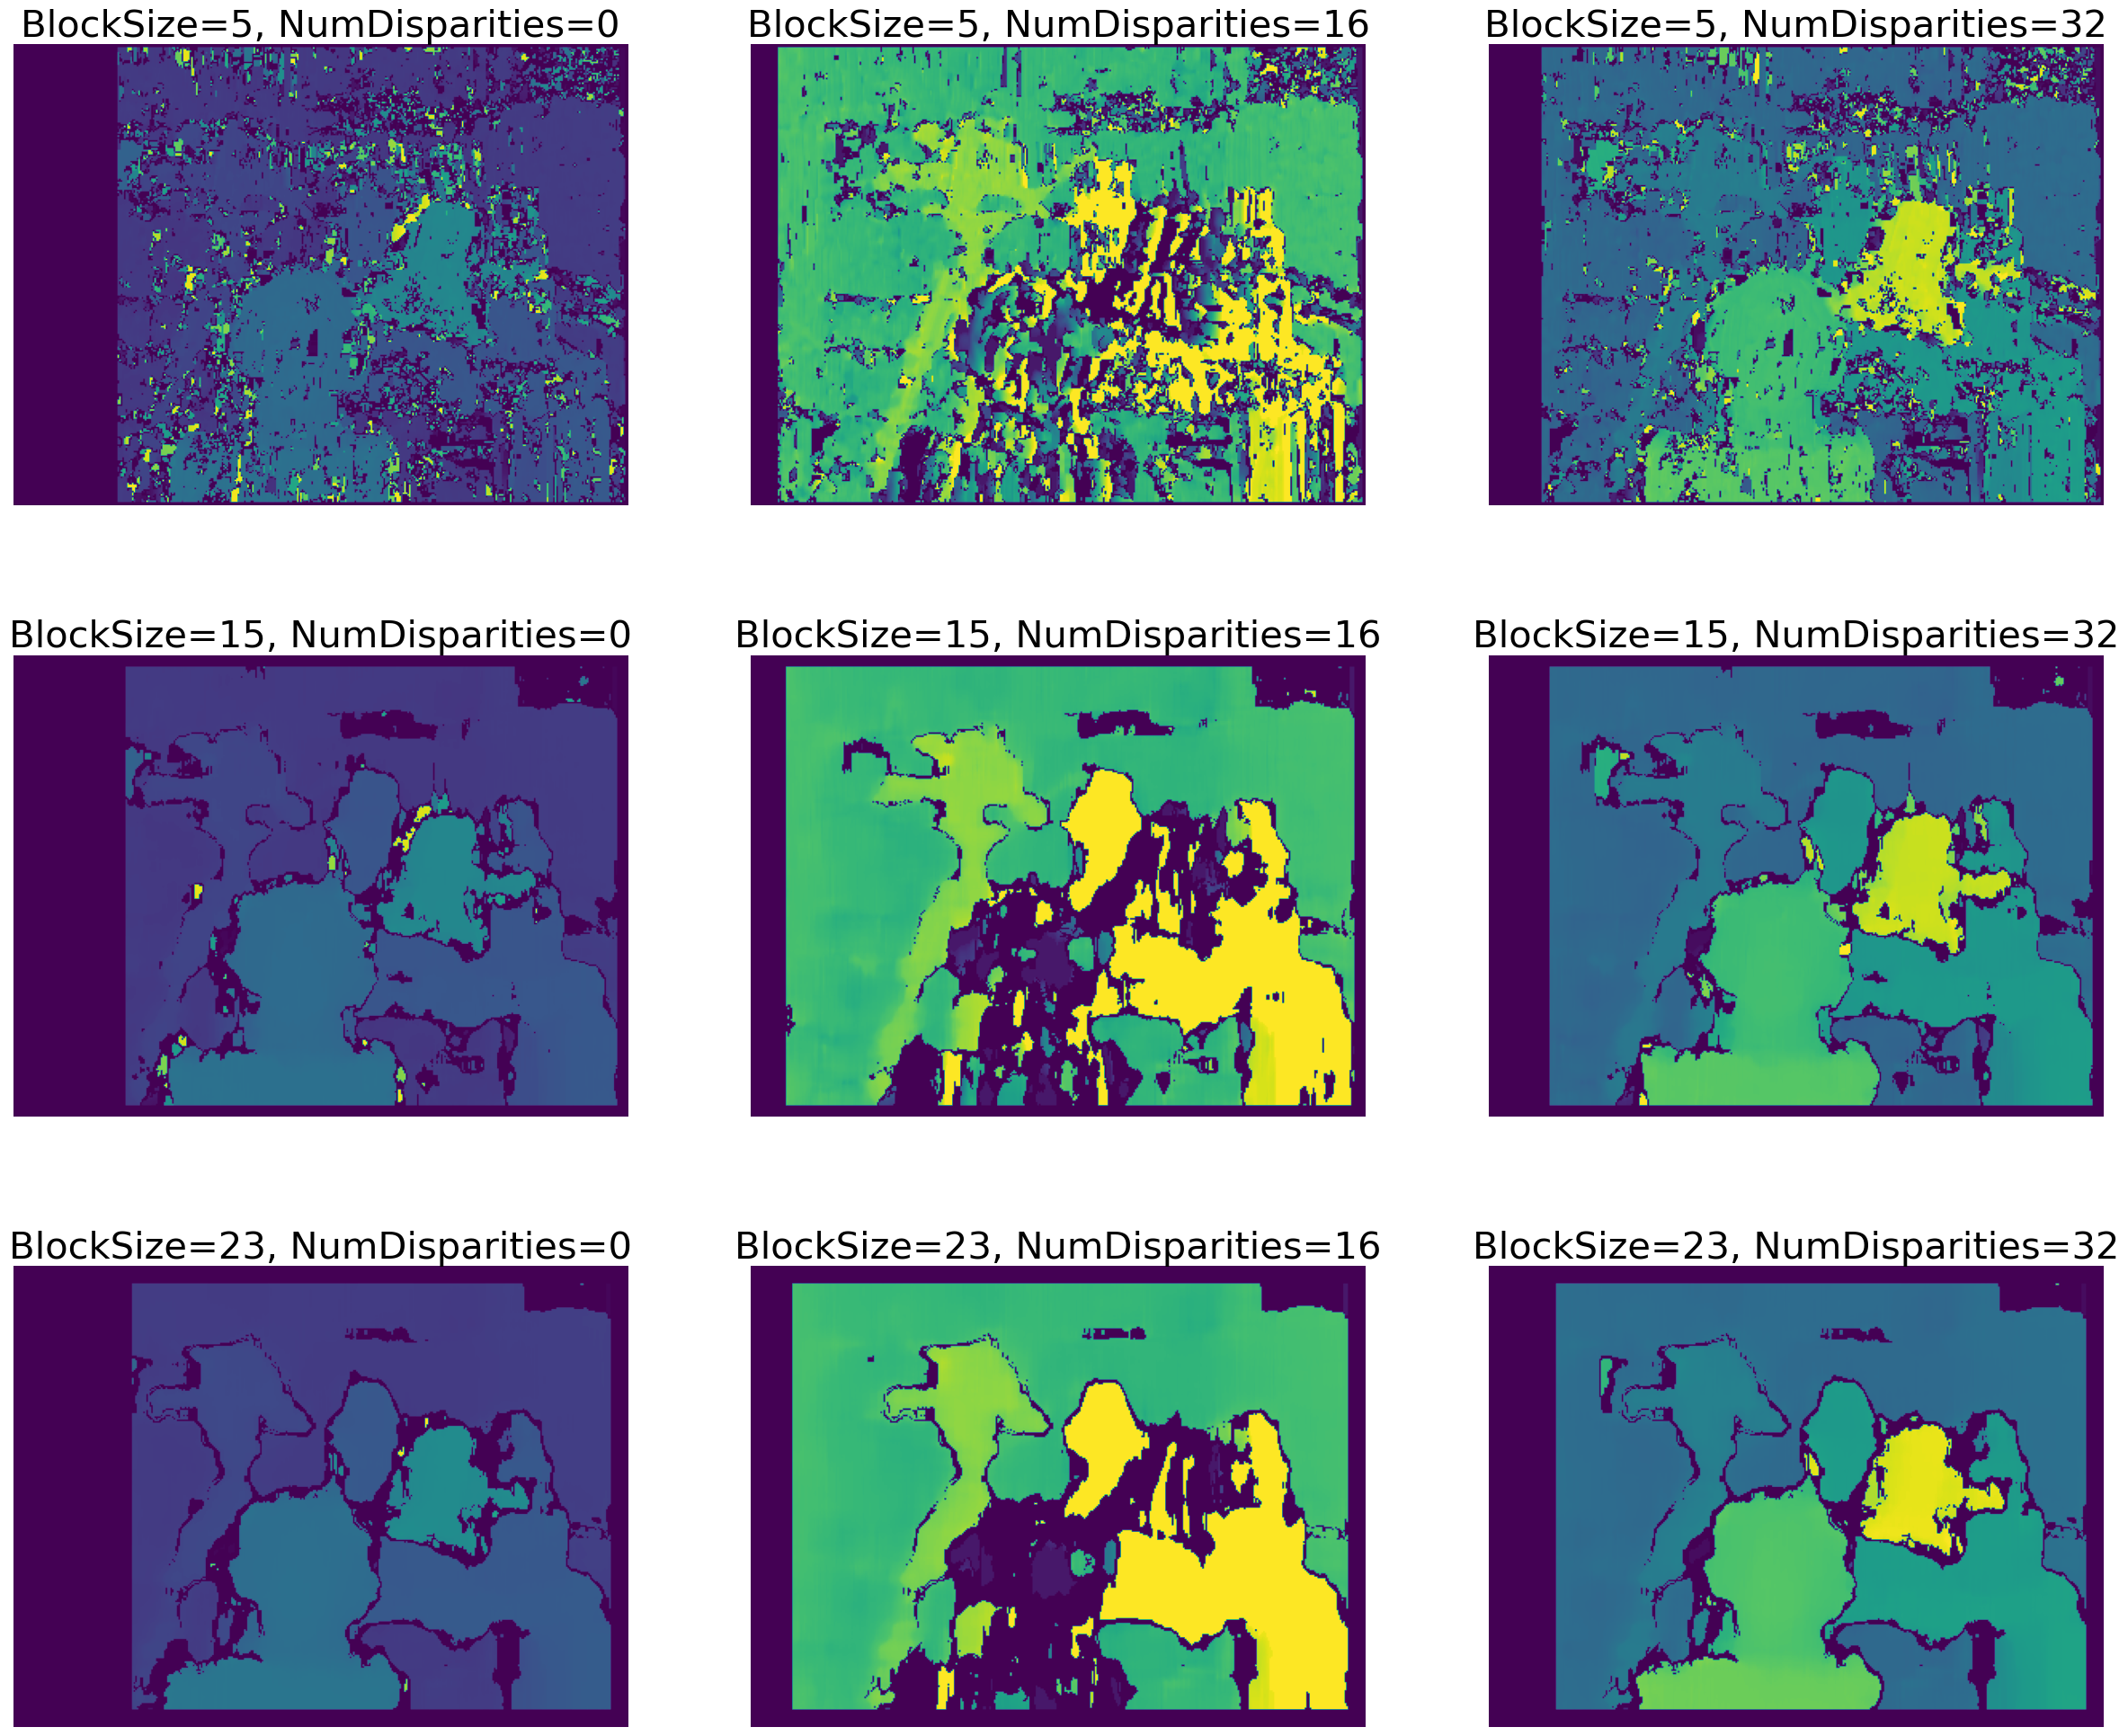

In [4]:

# Different block sizes and numDisparities to try
block_sizes = [5, 15, 23]
num_disparities_list = [0, 16, 32]

# Create a subplot grid with a larger image size and less space between columns
fig, axs = plt.subplots(len(block_sizes), len(num_disparities_list), figsize=(30, 25))
# plt.subplots_adjust(wspace=0.2, hspace=0.2)  # Adjust the space between columns

# Loop through different block sizes and numDisparities
for i, block_size in enumerate(block_sizes):
    for j, num_disparities in enumerate(num_disparities_list):
        # Stereo Block Matching
        stereo = cv.StereoBM_create(numDisparities=num_disparities, blockSize=block_size)
        disparity = stereo.compute(imgL, imgR)
        
        # Normalize and convert to uint8 for visualization
        disparity = cv.normalize(disparity, disparity, alpha=0, beta=255, norm_type=cv.NORM_MINMAX)
        disparity = np.uint8(disparity)
        
        # Plot the result with a larger title font size
        axs[i, j].imshow(disparity)
        axs[i, j].set_title(f'BlockSize={block_size}, NumDisparities={num_disparities}', fontsize=30)
        axs[i, j].axis('off')

plt.show()


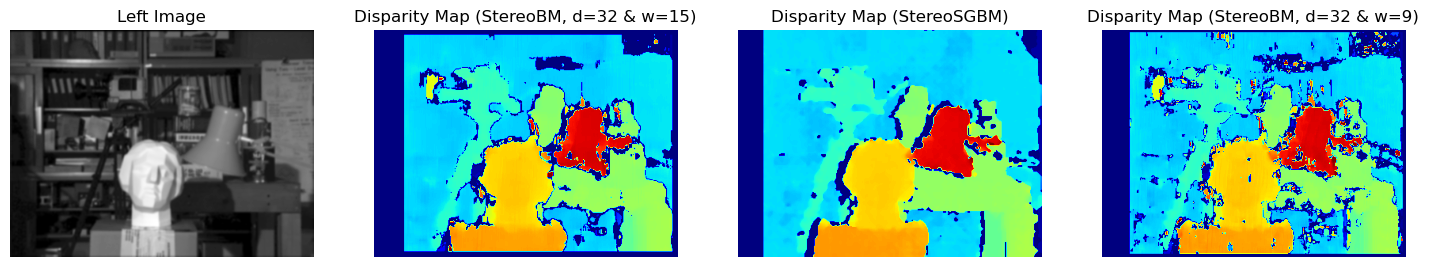

In [7]:

# Stereo Block Matching (StereoBM)
stereo_bm = cv.StereoBM_create(numDisparities=32, blockSize=15) 
disparity_bm = stereo_bm.compute(imgL, imgR)

# Stereo Semi-Global Block Matching (StereoSGBM)
stereo_sgbm = cv.StereoSGBM_create(
    minDisparity=0,
    numDisparities=32,
    blockSize=5,  
    P1=8 * 1 * 5**2,
    P2=16 * 1 * 5**2,
    disp12MaxDiff=1,
    uniquenessRatio=16,
    speckleWindowSize=100,
    speckleRange=2,
    preFilterCap=63,
    mode=cv.StereoSGBM_MODE_HH,
)
disparity_sgbm = stereo_sgbm.compute(imgL, imgR)

# Stereo Block Matching using cv2.StereoBM_create
stereo_bm_alt = cv.StereoBM_create(numDisparities=32, blockSize=9)
disparity_bm_alt = stereo_bm_alt.compute(imgL, imgR)

# Post-processing
def post_process_disparity(disparity):
    disparity = cv.normalize(disparity, disparity, alpha=0, beta=255, norm_type=cv.NORM_MINMAX)
    return np.uint8(disparity)

disparity_bm = post_process_disparity(disparity_bm)
disparity_sgbm = post_process_disparity(disparity_sgbm)
disparity_bm_alt = post_process_disparity(disparity_bm_alt)

# Plot the results
plt.figure(figsize=(18, 6))

plt.subplot(141), plt.imshow(imgL, cmap='gray'), plt.title('Left Image'), plt.axis('off')
plt.subplot(142), plt.imshow(disparity_bm, cmap='jet'), plt.title('Disparity Map (StereoBM, d=32 & w=15)'), plt.axis('off')
plt.subplot(143), plt.imshow(disparity_sgbm, cmap='jet'), plt.title('Disparity Map (StereoSGBM)'), plt.axis('off')
plt.subplot(144), plt.imshow(disparity_bm_alt, cmap='jet'), plt.title('Disparity Map (StereoBM, d=32 & w=9)'), plt.axis('off')

plt.show()
